In [1]:
%load_ext autoreload
%autoreload 2

Batching examples differently seems to lead to different outputs when using `torch.bfloat16`.

In [2]:
import matplotlib.pyplot as plt
from itertools import islice
import re

import tensor_tracker
import torch
import transformers

from training.eval.outcompare import EvalDataset

In [3]:
# Load the model
model_name = "meta-llama/Llama-3.2-11B-Vision-Instruct"
dtype = torch.bfloat16
model = transformers.MllamaForConditionalGeneration.from_pretrained(
    model_name, torch_dtype=dtype
)
model.to("cuda");

Loading checkpoint shards:   0%|          | 0/5 [00:00<?, ?it/s]

Test on evaluation dataset examples

In [4]:
# Get examples from the saved EvalDataset
ds = EvalDataset.load("data/llama-3.2-11b-vision-instruct.pt")

In [5]:
batch = ds.data[:4]

In [6]:
tokens = torch.stack([torch.cat([d.inp["input_ids"], d.completion]) for d in batch]).to(
    model.device
)

In [7]:
vision_kwargs = {}
for k in ["pixel_values", "aspect_ratio_ids", "aspect_ratio_mask"]:
    if k in batch[0].inp:
        vision_kwargs[k] = torch.stack([d.inp[k] for d in batch]).to(
            model.device
        )

In [8]:
# Pass the full batch
with tensor_tracker.track(model, grad=False) as tracker1, torch.no_grad():
    model(tokens, **vision_kwargs)

In [9]:
# Pass the first element of the batch
with tensor_tracker.track(model, grad=False) as tracker2, torch.no_grad():
    model(tokens[:1], **{k: v[:1] for k, v in vision_kwargs.items()})

In [10]:
skipping = False
for x in tracker1:
    layer_n = re.search(r"(\d)+", x.name)
    if (not layer_n) or int(layer_n.group(0)) == 0:
        if isinstance(x.first_value, torch.Tensor):
            print(f"{x.name} {x.first_value.shape}")
            skipping = False
    elif not skipping:
        print("...")
        skipping = True

vision_model.patch_embedding torch.Size([16, 1280, 40, 40])
vision_model.pre_tile_positional_embedding.embedding torch.Size([4, 1, 5120])
vision_model.pre_tile_positional_embedding torch.Size([4, 4, 1600, 1280])
vision_model.gated_positional_embedding.tile_embedding torch.Size([4, 1, 8197120])
vision_model.gated_positional_embedding torch.Size([4, 4, 1601, 1280])
vision_model.layernorm_pre torch.Size([4, 4, 1601, 1280])
vision_model.transformer.layers.0.input_layernorm torch.Size([4, 6432, 1280])
vision_model.transformer.layers.0.self_attn.q_proj torch.Size([4, 6432, 1280])
vision_model.transformer.layers.0.self_attn.k_proj torch.Size([4, 6432, 1280])
vision_model.transformer.layers.0.self_attn.v_proj torch.Size([4, 6432, 1280])
vision_model.transformer.layers.0.self_attn.o_proj torch.Size([4, 6432, 1280])
vision_model.transformer.layers.0.self_attn torch.Size([4, 6432, 1280])
vision_model.transformer.layers.0.post_attention_layernorm torch.Size([4, 6432, 1280])
vision_model.transforme

In [11]:
skipping = False
for x in tracker2:
    layer_n = re.search(r"(\d)+", x.name)
    if (not layer_n) or int(layer_n.group(0)) == 0:
        if isinstance(x.first_value, torch.Tensor):
            print(f"{x.name} {x.first_value.shape}")
            skipping = False
    elif not skipping:
        print("...")
        skipping = True

vision_model.patch_embedding torch.Size([4, 1280, 40, 40])
vision_model.pre_tile_positional_embedding.embedding torch.Size([1, 1, 5120])
vision_model.pre_tile_positional_embedding torch.Size([1, 4, 1600, 1280])
vision_model.gated_positional_embedding.tile_embedding torch.Size([1, 1, 8197120])
vision_model.gated_positional_embedding torch.Size([1, 4, 1601, 1280])
vision_model.layernorm_pre torch.Size([1, 4, 1601, 1280])
vision_model.transformer.layers.0.input_layernorm torch.Size([1, 6432, 1280])
vision_model.transformer.layers.0.self_attn.q_proj torch.Size([1, 6432, 1280])
vision_model.transformer.layers.0.self_attn.k_proj torch.Size([1, 6432, 1280])
vision_model.transformer.layers.0.self_attn.v_proj torch.Size([1, 6432, 1280])
vision_model.transformer.layers.0.self_attn.o_proj torch.Size([1, 6432, 1280])
vision_model.transformer.layers.0.self_attn torch.Size([1, 6432, 1280])
vision_model.transformer.layers.0.post_attention_layernorm torch.Size([1, 6432, 1280])
vision_model.transformer

Note! Some vision parts have a leading dimension of `batch_size * 4` and not `batch_size`! (`patch_embedding` and also `k` and `v` projections in cross attention layers)

In [12]:
# Find first layer where tensors are not the same
for x1, x2 in zip(tracker1, tracker2):
    assert x1.name == x2.name
    if isinstance(x1.first_value, torch.Tensor):
        if not torch.allclose(x1.first_value[:1], x2.first_value[:1]):
            print(x1.name)
            print(x1.first_value[:1] - x2.first_value)
            break

language_model.model.layers.0.self_attn.k_proj
tensor([[[ 0.0000, -0.0039,  0.0000,  ..., -0.0156,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0039,  ...,  0.0000, -0.0007, -0.0020],
         [ 0.0000, -0.0039,  0.0000,  ..., -0.0156,  0.0000,  0.0000],
         ...,
         [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]]],
       dtype=torch.bfloat16)


Look at the `self_attn.k_proj` layer on its own

In [13]:
# Try passing a random input to the k_proj linear layer
torch.manual_seed(100)
x = torch.randn(4, 70, 4096, dtype=torch.bfloat16, device=model.device)

In [14]:
module = model.language_model.model.layers[0].self_attn.k_proj

In [15]:
def err(x1: torch.Tensor, x2: torch.Tensor) -> float:
    return (((x1.float() - x2.float()) ** 2).sum() / (x1.float() ** 2).sum()).item()

In [16]:
y1 = module(x)[:1]
y2 = module(x[:1])
print(f"torch.allclose: {torch.allclose(y1[:1], y2)}")
print(f"Error:          {err(y1, y2)}")

torch.allclose: False
Error:          6.774760549888015e-06


Just doing the matmul

In [17]:
# Is it the same when just doing matmul with the weight?
y1 = (x @ module.weight.T)[:1]
y2 = x[:1] @ module.weight.T
print(f"torch.allclose: {torch.allclose(y1[:1], y2)}")
print(f"Error:          {err(y1, y2)}")

torch.allclose: False
Error:          6.774760549888015e-06


`fp16` has smaller error

In [18]:
# How about fp16 instead of bfloat16?
y1 = (x.half() @ module.weight.T.half())[:1]
y2 = x[:1].half() @ module.weight.T.half()
print(f"torch.allclose: {torch.allclose(y1[:1], y2)}")
print(f"Error (fp16):   {err(y1, y2)}")

torch.allclose: False
Error (fp16):   2.196697934664371e-09


Error throughout the network

In [19]:
# Plot error throughout the network
errs = {
    # x1.name: err(x1.first_value[:1], x2.first_value[:1])
    x1.name: err(x1.first_value[: x1.first_value.size(0) // 4], x2.first_value)
    for x1, x2 in zip(tracker1, tracker2)
    if isinstance(x1.first_value, torch.Tensor)
}

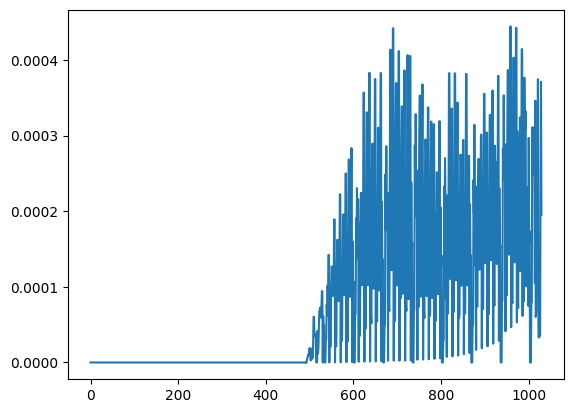

In [20]:
plt.plot(errs.values())
plt.show()

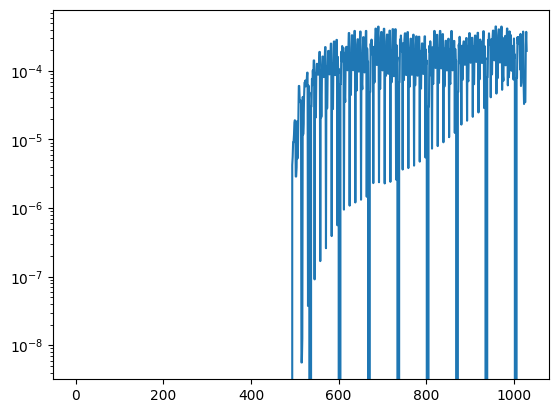

In [21]:
plt.plot(errs.values())
plt.gca().set_yscale("log")
plt.show()